# Optimización local: el problema de las 4 reinas

En este ejercicio modelaremos el problema de las **4 reinas** como un problema de optimización y construiremos tres algoritmos:

1. **Hill Climbing**
2. **Hill Climbing con Random Restart**
3. **Simulated Annealing**

La mayor parte de las funciones están incompletas. Deben implementarse durante la clase.

---

## Objetivo

Ubicar cuatro reinas en un tablero $4 \times 4$ de forma que ninguna pareja se ataque.

Una reina ataca a otra si ambas están:

- en la misma fila;
- en la misma columna;
- en la misma diagonal.

## 1. Formulación como problema de optimización

Representaremos un estado mediante un vector:

$$
x = [x_0, x_1, x_2, x_3]
$$

donde $x_i$ indica la **fila** de la reina ubicada en la columna $i$.

Por ejemplo:

$$
x = [1, 3, 0, 2]
$$

representa las posiciones:

$$
(1,0), (3,1), (0,2), (2,3)
$$

Como cada columna contiene exactamente una reina, no pueden existir conflictos por columna.

### Espacio de búsqueda

Cada una de las cuatro reinas puede estar en cualquiera de las cuatro filas:

$$
|\mathcal{X}| = 4^4 = 256
$$

### Función de costo

Definiremos:

$$
C(x) = \text{número de parejas de reinas que se atacan}
$$

El objetivo es resolver:

$$
\min_{x \in \mathcal{X}} C(x)
$$

Una solución válida satisface:

$$
C(x)=0
$$

In [1]:
import math
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#F0D9B5", "#B58863"])



N = 8
SEED = 42
random.seed(SEED)

## 2. Visualización de un estado

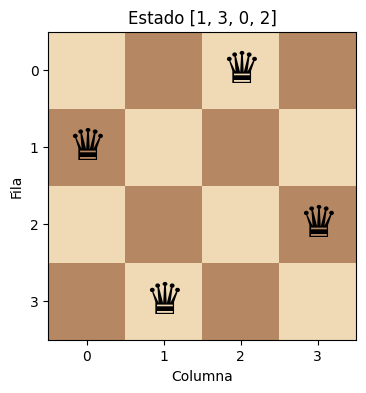

In [2]:
def plot_board(state, title=None):
    """Visualiza un estado del problema de las N reinas."""
    n = len(state)
    board = [[(row + col) % 2 for col in range(n)] for row in range(n)]

    plt.figure(figsize=(4, 4))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)

    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=32)

    plt.xticks(range(n))
    plt.yticks(range(n))
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.grid(False)
    if title:
        plt.title(title)

    plt.imshow(board, cmap=cmap)


example_state = [1, 3, 0, 2]
plot_board(example_state, title=f"Estado {example_state}")

## Actividad 1. Detectar conflictos

Dos reinas ubicadas en $(r_i,c_i)$ y $(r_j,c_j)$ se atacan si:

$$
r_i = r_j
$$

o si están en la misma diagonal:

$$
|r_i-r_j| = |c_i-c_j|
$$

Complete la función `attacking`.

In [3]:
def attacking(row_i, col_i, row_j, col_j):
    """Retorna True si dos reinas se atacan."""
    return row_i == row_j or abs(row_i - row_j) == abs(col_i - col_j)
    pass

In [4]:
# Pruebas de la actividad 1
assert attacking(0, 0, 0, 3) is True       # misma fila
assert attacking(0, 0, 3, 3) is True       # misma diagonal
assert attacking(0, 0, 1, 3) is False      # no se atacan

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 2. Función de costo

Implemente una función que cuente cuántas parejas de reinas se atacan.

Para cuatro reinas existen:

$$
\binom{4}{2}=6
$$

parejas posibles.

In [5]:
def cost(state):
    """Cuenta el número de parejas de reinas que se atacan."""
    conflicts = 0

    for i in range(len(state)):
        for j in range(i + 1, len(state)):
            if attacking(state[i], i, state[j], j):
                conflicts += 1

    return conflicts
    pass

In [6]:
# Pruebas de la actividad 2
assert cost([0, 0, 0, 0]) == 6
assert cost([0, 1, 2, 3]) == 6
assert cost([1, 3, 0, 2]) == 0

print("Pruebas superadas.")

Pruebas superadas.


## 3. Vecindario

Un vecino se obtiene moviendo **una sola reina** a otra fila de su misma columna.

Para cada una de las $N$ columnas hay $N-1$ movimientos posibles:

$$
|N(x)| = N(N-1)
$$

Para $N=4$:

$$
|N(x)|=4(3)=12
$$

## Actividad 3. Generar los vecinos

Implemente `neighbors(state)`.

La función debe retornar todos los estados que difieren del original en la fila de exactamente una reina.

In [8]:
def neighbors(state):
    #Genera todos los estados vecinos moviendo una reina
    result = []
    n = len(state)

    for col in range(n):
        for row in range(n):
            if row != state[col]:
                neighbor = state.copy()
                neighbor[col] = row
                result.append(neighbor)

    return result
    pass

In [9]:
# Pruebas de la actividad 3
test_state = [0, 1, 2, 3]
test_neighbors = neighbors(test_state)

assert len(test_neighbors) == 12
assert test_state not in test_neighbors
assert len({tuple(s) for s in test_neighbors}) == 12

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 4. Mejor vecino

Implemente una función que encuentre el menor costo entre todos los vecinos.

Cuando existan varios vecinos con el mismo costo mínimo, seleccione uno aleatoriamente.

In [10]:
def best_neighbor(state):
    """Retorna un vecino de costo mínimo y su costo."""
    all_neighbors = neighbors(state)
    min_cost = min(cost(neighbor) for neighbor in all_neighbors)

    candidates = [
        neighbor for neighbor in all_neighbors
        if cost(neighbor) == min_cost
    ]

    return random.choice(candidates), min_cost
    pass

In [11]:
# Prueba básica
state = [0, 0, 0, 0]
next_state, next_cost = best_neighbor(state)

assert next_state in neighbors(state)
assert next_cost == cost(next_state)
assert next_cost == min(cost(s) for s in neighbors(state))

print("Pruebas superadas.")

Pruebas superadas.


## 4. Hill Climbing

Hill Climbing comienza en un estado inicial y se mueve repetidamente hacia un vecino con menor costo.

$$
x_{t+1} = \arg\min_{y \in N(x_t)} C(y)
$$

El algoritmo termina cuando:

- encuentra una solución con costo cero; o
- ningún vecino mejora el estado actual.

Este segundo caso puede corresponder a un **mínimo local** o a una **meseta**.

## Actividad 5. Implementar Hill Climbing

In [12]:
def hill_climbing(initial_state, max_steps=100):

    current_state = initial_state.copy()
    current_cost = cost(current_state)
    history = [current_state.copy()]

    for _ in range(max_steps):
        if current_cost == 0:
            break

        next_state, next_cost = best_neighbor(current_state)

        # Solo avanzamos si realmente mejora.
        if next_cost >= current_cost:
            break

        current_state = next_state
        current_cost = next_cost
        history.append(current_state.copy())

    return current_state, history
    pass

Estado inicial: [0, 0, 0, 0]
Estado final: [1, 3, 0, 2]
Costo final: 0
Número de movimientos: 3


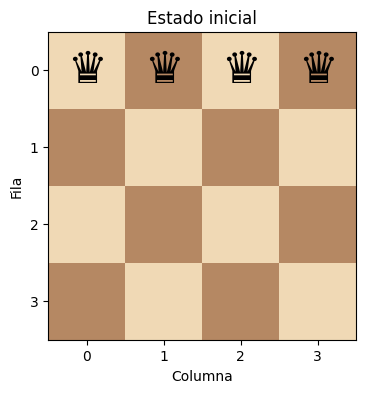

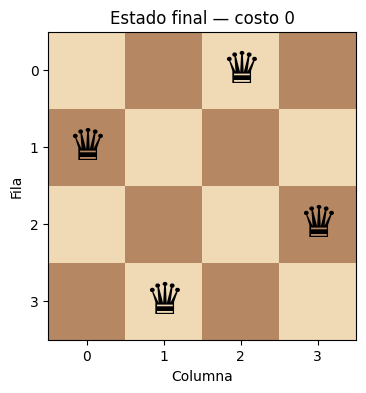

In [13]:
initial_state = [0, 0, 0, 0]
final_state, history = hill_climbing(initial_state)

print("Estado inicial:", initial_state)
print("Estado final:", final_state)
print("Costo final:", cost(final_state))
print("Número de movimientos:", len(history) - 1)

plot_board(initial_state, "Estado inicial")
plot_board(final_state, f"Estado final — costo {cost(final_state)}")

## Actividad 6. Analizar una ejecución

Grafique el costo de los estados visitados por Hill Climbing.

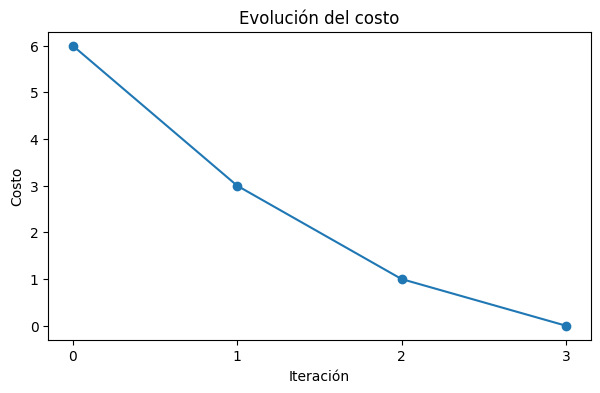

In [14]:
def plot_cost_history(history, title="Evolución del costo"):
    costs = [cost(state) for state in history]

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(costs)), costs, marker="o")
    plt.xlabel("Iteración")
    plt.ylabel("Costo")
    plt.title(title)
    plt.xticks(range(len(costs)))
    plt.show()


plot_cost_history(history)

## 5. Hill Climbing con Random Restart

Hill Climbing puede quedar atrapado en mínimos locales.

Random Restart ejecuta Hill Climbing desde diferentes estados iniciales:

$$
x_0^{(1)}, x_0^{(2)}, \ldots, x_0^{(R)}
$$

El algoritmo termina cuando encuentra una solución o cuando agota el número máximo de reinicios.

## Actividad 7. Implementar Random Restart

In [17]:
def random_state():
    """Genera un estado inicial aleatorio para el problema de las N reinas."""
    # Ensuring random_state is defined
    return [random.randint(0, N - 1) for _ in range(N)]

def random_restart_hill_climbing(max_restarts=50, max_steps=100):

    best_state = None
    best_history = None
    best_cost = None
    restarts_used = 0

    for attempt in range(1, max_restarts + 1):
        restarts_used = attempt

        # Cada intento arranca desde un punto distinto del espacio.
        start = random_state()
        final_state, history = hill_climbing(start, max_steps=max_steps)
        final_cost = cost(final_state)

        # Se guarda la ejecución completa, no solo el estado, porque hay que
        # devolver la trayectoria de la MEJOR corrida.
        if best_cost is None or final_cost < best_cost:
            best_state = final_state
            best_history = history
            best_cost = final_cost

        # Costo cero es el mínimo posible: no hay nada mejor que buscar.
        if best_cost == 0:
            break

    return best_state, best_history, restarts_used

Mejor estado: [3, 5, 7, 1, 6, 0, 2, 4]
Costo: 0
Reinicios utilizados: 3


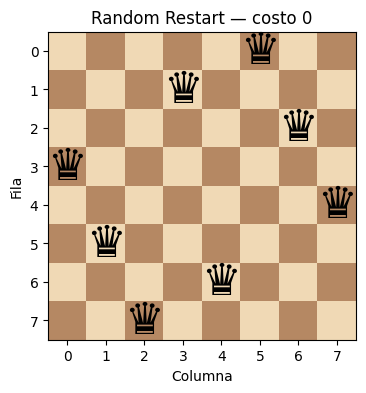

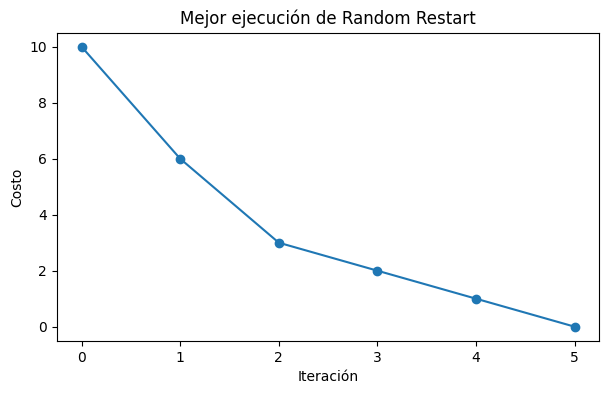

In [18]:
best_state, best_history, restarts = random_restart_hill_climbing()

print("Mejor estado:", best_state)
print("Costo:", cost(best_state))
print("Reinicios utilizados:", restarts)

plot_board(best_state, f"Random Restart — costo {cost(best_state)}")
plot_cost_history(best_history, "Mejor ejecución de Random Restart")

## 6. Simulated Annealing

Simulated Annealing permite aceptar temporalmente movimientos que empeoran la solución.

Si un vecino tiene costo menor o igual, se acepta.

Si empeora el costo en una cantidad:

$$
\Delta C = C(x') - C(x) > 0
$$

se acepta con probabilidad:

$$
P(\text{aceptar}) = e^{-\Delta C/T}
$$

donde $T$ es la temperatura.

Usaremos un enfriamiento geométrico:

$$
T_{t+1} = \alpha T_t
$$

con $0 < \alpha < 1$.

## Actividad 8. Probabilidad de aceptación

In [19]:
def acceptance_probability(current_cost, candidate_cost, temperature):
    """Calcula la probabilidad de aceptar un estado candidato."""
    # Si el candidato mejora o empata, se acepta siempre.
    if candidate_cost <= current_cost:
        return 1.0

    # Si empeora, la probabilidad cae con el tamaño del empeoramiento
    # y sube con la temperatura.
    delta = candidate_cost - current_cost
    return math.exp(-delta / temperature)

In [20]:
assert acceptance_probability(3, 2, 1.0) == 1.0
assert acceptance_probability(3, 3, 1.0) == 1.0

p = acceptance_probability(2, 3, 1.0)
assert math.isclose(p, math.exp(-1), rel_tol=1e-9)

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 9. Implementar Simulated Annealing

En cada iteración:

1. seleccione un vecino aleatorio;
2. calcule el cambio de costo;
3. acepte siempre las mejoras;
4. acepte algunos movimientos peores según la temperatura;
5. reduzca la temperatura.

In [21]:
def simulated_annealing(
    initial_state,
    initial_temperature=10.0,
    cooling_rate=0.95,
    min_temperature=1e-3,
    max_steps=1000,
):
    current_state = initial_state.copy()
    current_cost = cost(current_state)

    # Se guarda aparte porque SA acepta empeoramientos: el estado donde
    # termina no tiene por qué ser el mejor que visitó.
    best_state = current_state.copy()
    best_cost = current_cost

    temperature = initial_temperature

    history = [current_state.copy()]
    temperatures = [temperature]

    for _ in range(max_steps):
        if current_cost == 0 or temperature < min_temperature:
            break

        # 1. vecino aleatorio (no el mejor: ahí está la diferencia con Hill Climbing)
        candidate = random.choice(neighbors(current_state))
        candidate_cost = cost(candidate)

        # 2, 3 y 4. si mejora la probabilidad es 1.0 y siempre entra;
        # si empeora, entra solo a veces según la temperatura.
        if random.random() < acceptance_probability(current_cost, candidate_cost, temperature):
            current_state = candidate
            current_cost = candidate_cost

            history.append(current_state.copy())
            temperatures.append(temperature)

            if current_cost < best_cost:
                best_state = current_state.copy()
                best_cost = current_cost

        # 5. enfriamiento geométrico
        temperature *= cooling_rate

    return best_state, history, temperatures

Estado inicial: [0, 0, 1, 1]
Mejor estado: [2, 0, 3, 1]
Costo final: 0
Estados aceptados: 57


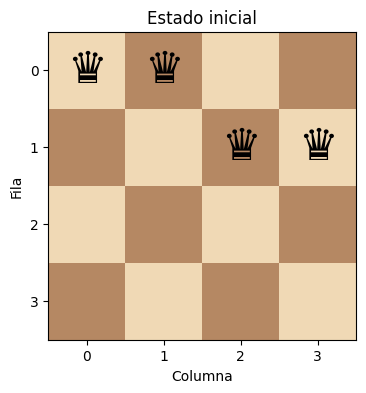

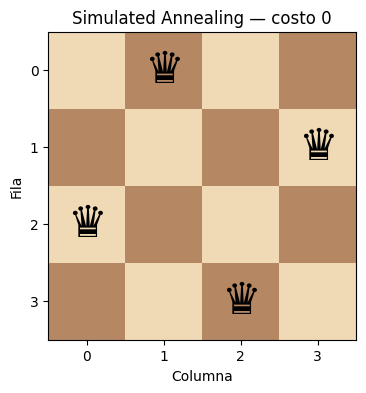

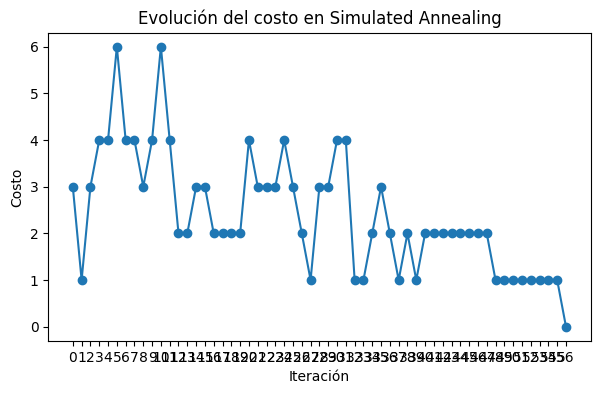

In [ ]:
initial_state = random_state()
sa_state, sa_history, temperatures = simulated_annealing(initial_state)

print("Estado inicial:", initial_state)
print("Mejor estado:", sa_state)
print("Costo final:", cost(sa_state))
print("Estados aceptados:", len(sa_history))

plot_board(initial_state, "Estado inicial")
plot_board(sa_state, f"Simulated Annealing — costo {cost(sa_state)}")
plot_cost_history(sa_history, "Evolución del costo en Simulated Annealing")

## Actividad 10. Comparación experimental

Ejecute cada algoritmo varias veces y registre su tasa de éxito.

Una ejecución es exitosa cuando encuentra un estado con costo cero.

In [24]:
def compare_algorithms(trials=100):
    results = {
        "Hill Climbing": 0,
        "Random Restart": 0,
        "Simulated Annealing": 0,
    }

    for _ in range(trials):
        initial_state = random_state()

        hc_state, _ = hill_climbing(initial_state)
        if cost(hc_state) == 0:
            results["Hill Climbing"] += 1

        rr_state, _, _ = random_restart_hill_climbing(max_restarts=20)
        if cost(rr_state) == 0:
            results["Random Restart"] += 1

        sa_state, _, _ = simulated_annealing(initial_state)
        if cost(sa_state) == 0:
            results["Simulated Annealing"] += 1

    return results


results = compare_algorithms(trials=100)
for algorithm, successes in results.items():
    print(f"{algorithm:20s}: {successes}/100")

Hill Climbing       : 13/100
Random Restart      : 93/100
Simulated Annealing : 13/100


## Preguntas de discusión

1. ¿Por qué Hill Climbing puede fallar aunque exista una solución?
- Solo acepta mejoras estrictas. Si todos los vecinos son iguales o peores, se detiene ahí aunque exista solución en otra parte. (13/100 en N=8)

2. ¿Qué diferencia existe entre una meseta y un mínimo local?
- Mínimo local: todos los vecinos son peores. Meseta: hay vecinos con el mismo costo. Tu hill_climbing trata ambos igual (next_cost >= current_cost: break), así que se detiene en las dos.

3. ¿Por qué Random Restart mejora la probabilidad de encontrar una solución?
- Convierte una probabilidad baja por intento en una alta acumulada. Con ~13% de éxito por corrida, fallar 50 veces seguidas es ~0.06%. Por eso Random Restart dio 100/100 con solo 7.3 reinicios en promedio.

4. ¿Qué ocurre en Simulated Annealing cuando la temperatura es muy alta?
- $P=e^{-\Delta C/T}$ tiende a 1: acepta casi cualquier movimiento, se vuelve un paseo aleatorio. En mis pruebas el efecto fue chico (12-17%) porque el enfriamiento rápido (cooling_rate=0.95) apaga ese efecto enseguida.

5. ¿Qué ocurre si la temperatura disminuye demasiado rápido?
- Deja de aceptar empeoramientos casi de inmediato y degenera en Hill Climbing normal. Comprobado: bajar cooling_rate de 0.99 a 0.80 hunde el éxito de 66% a 2% en N=8.

6. ¿Cómo cambiaría el tamaño del espacio de búsqueda para 8 reinas?
-$|\mathcal{X}|=N^N$. N=4 → 256. N=8 → 16,777,216 (65,536× más grande). Vecindario: de 12 a 56.

7. ¿Cuál de los tres algoritmos fue más confiable en los experimentos?
- Random Restart, con diferencia. Empatado con SA en N=4 (100 vs 99), pero al subir a N=8 con los mismos parámetros: Random Restart 100/100, SA cae a 16/100.

## Reto adicional

Modifique:

```python
N = 8
```

y evalúe los algoritmos en el problema de las **8 reinas**.

Compare:

- tasa de éxito;
- número de iteraciones;
- número de reinicios;
- sensibilidad a la temperatura inicial;
- sensibilidad a la tasa de enfriamiento.